In [20]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

print("Path to dataset:", path)
print("\nFiles and folders inside:")
print(os.listdir(path))

Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Path to dataset: /kaggle/input/fashion-product-images-dataset

Files and folders inside:
['fashion-dataset']


In [21]:
import os

sub_path = os.path.join(path, "fashion-dataset")
print("Path inside dataset:", sub_path)
print("\nFiles and folders inside:")
print(os.listdir(sub_path))

Path inside dataset: /kaggle/input/fashion-product-images-dataset/fashion-dataset

Files and folders inside:
['images.csv', 'images', 'styles.csv', 'styles', 'fashion-dataset']


In [22]:
import pandas as pd

styles_path = os.path.join(sub_path, "styles.csv")
styles_df = pd.read_csv(styles_path, on_bad_lines="skip")

print("Shape of styles.csv:", styles_df.shape)
print("\nColumns in styles.csv:\n", styles_df.columns.tolist())

# Display first few rows
styles_df.head()

Shape of styles.csv: (44424, 10)

Columns in styles.csv:
 ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [23]:
import os

images_path = os.path.join(sub_path, "images")
image_files = os.listdir(images_path)

# Extract IDs from image filenames (they're usually named like "12345.jpg")
image_ids = [int(f.split('.')[0]) for f in image_files if f.endswith('.jpg')]

# Filter styles_df to keep only rows that have an image
styles_df = styles_df[styles_df['id'].isin(image_ids)]

print("Total images available:", len(image_files))
print("Total matched entries in styles.csv:", len(styles_df))
styles_df.head()

Total images available: 44441
Total matched entries in styles.csv: 44419


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


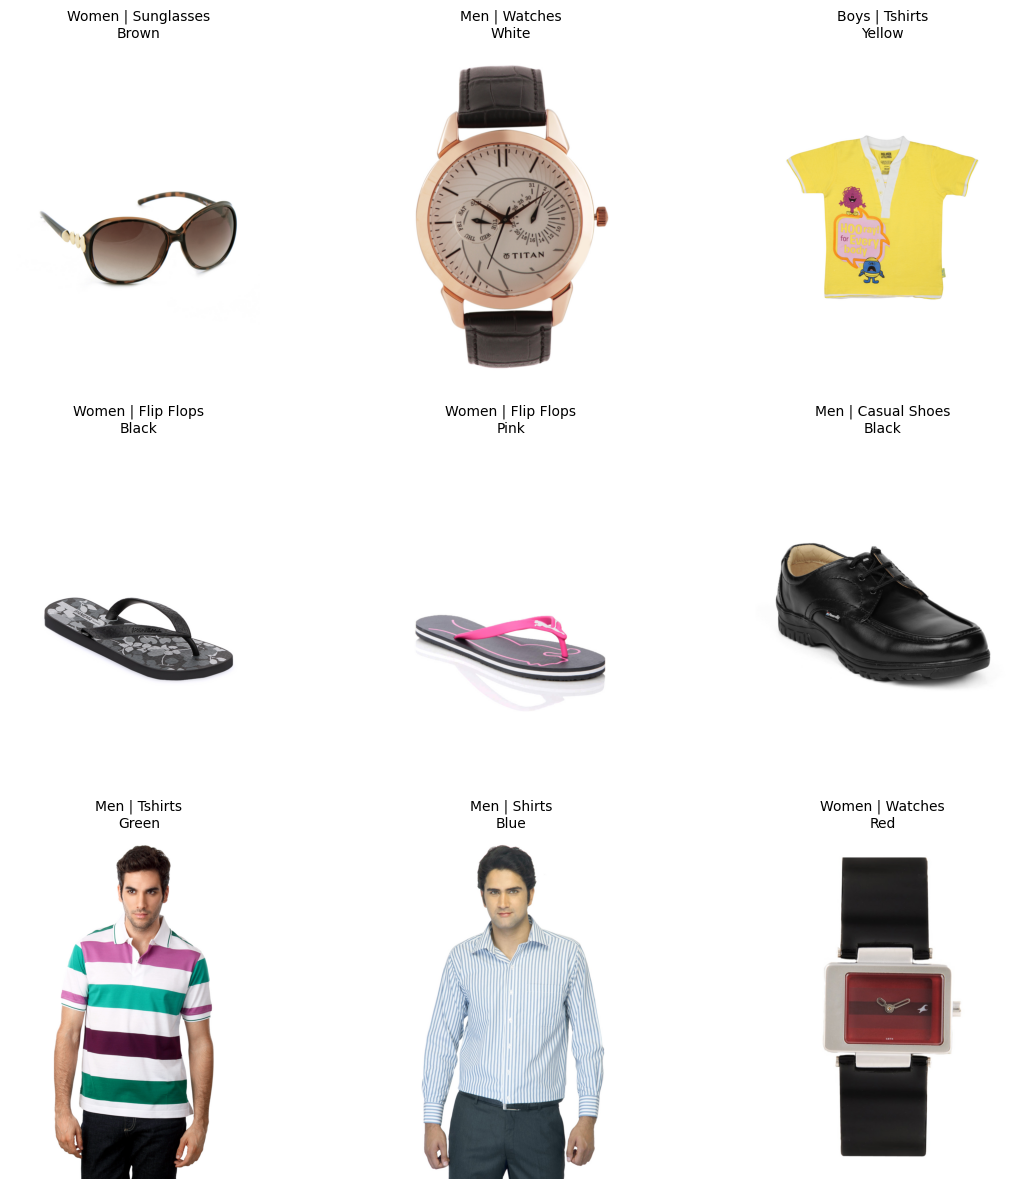

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Create image path column
styles_df["image_path"] = styles_df["id"].apply(lambda x: os.path.join(images_path, f"{x}.jpg"))

# Display some random samples
sample_df = styles_df.sample(9, random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 12))

for i, row in sample_df.iterrows():
    plt.subplot(3, 3, i + 1)
    img = Image.open(row["image_path"])
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{row['gender']} | {row['articleType']}\n{row['baseColour']}", fontsize=10)

plt.tight_layout()
plt.show()

In [25]:
from PIL import Image
import numpy as np

# Sample 500 image paths for quick dimension check
sample_paths = styles_df["image_path"].sample(500, random_state=42)

widths, heights = [], []

for img_path in sample_paths:
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print("Number of images checked:", len(widths))
print(f"Average width: {np.mean(widths):.2f}")
print(f"Average height: {np.mean(heights):.2f}")
print(f"Min width: {np.min(widths)} Max width: {np.max(widths)}")
print(f"Min height: {np.min(heights)} Max height: {np.max(heights)}")

Number of images checked: 500
Average width: 1399.27
Average height: 1866.28
Min width: 150 Max width: 1806
Min height: 200 Max height: 2700


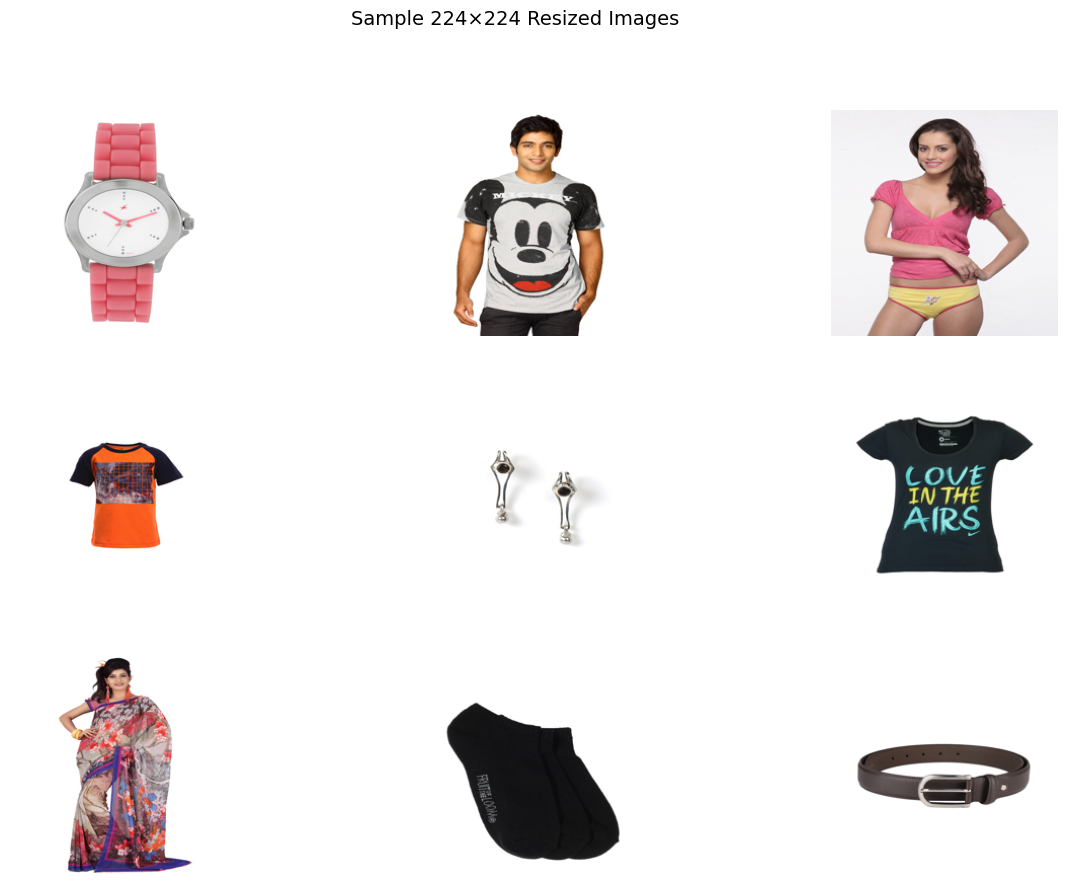

In [26]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# Randomly sample 9 images from the dataset
sample_paths = random.sample(list(styles_df["image_path"]), 9)

plt.figure(figsize=(15, 10))
for i, path in enumerate(sample_paths):
    img = Image.open(path).resize((224, 224))
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle("Sample 224×224 Resized Images", fontsize=14)
plt.show()

In [27]:
import google.protobuf
from google.protobuf import descriptor_pb2
if not hasattr(descriptor_pb2, "FileDescriptorProto"):
    from google.protobuf import descriptor
    descriptor_pb2.FileDescriptorProto = descriptor.FileDescriptorProto

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Protobuf version:", google.protobuf.__version__)

TensorFlow version: 2.19.0
Protobuf version: 5.29.5


In [28]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
from tqdm import tqdm
import time

# Load pre-trained VGG16 (without classifier head)
vgg_model = VGG16(weights="imagenet", include_top=False, pooling='avg', input_shape=(224, 224, 3))
vgg_model.trainable = False

def extract_features_batch(df, batch_size=64):
    features = []
    total_batches = len(df) // batch_size + 1
    start_time = time.time()

    for i in range(0, len(df), batch_size):
        batch_no = i // batch_size + 1
        batch_paths = df["image_path"].iloc[i:i+batch_size]
        batch_images = []

        for path in batch_paths:
            try:
                img = image.load_img(path, target_size=(224, 224))
                img_array = image.img_to_array(img)
                batch_images.append(img_array)
            except:
                batch_images.append(np.zeros((224, 224, 3)))

        batch_images = np.array(batch_images)
        batch_images = preprocess_input(batch_images)

        # Extract features
        batch_features = vgg_model.predict(batch_images, verbose=0)
        features.extend(batch_features)

        # Print progress every 10 batches
        if batch_no % 10 == 0 or batch_no == total_batches:
            elapsed = (time.time() - start_time) / 60
            print(f"Completed batch {batch_no}/{total_batches} — Elapsed: {elapsed:.2f} mins")

    return np.array(features)

filtered_df = styles_df.reset_index(drop=True)
print("Starting VGG16 feature extraction...")
print("Total images:", len(filtered_df))
print("Expected batches:", len(filtered_df)//64 + 1)

features = extract_features_batch(filtered_df, batch_size=64)
print("Feature extraction completed.")
print("Feature array shape:", features.shape)

Starting VGG16 feature extraction...
Total images: 44419
Expected batches: 695
Completed batch 10/695 — Elapsed: 0.31 mins
Completed batch 20/695 — Elapsed: 0.61 mins
Completed batch 30/695 — Elapsed: 0.91 mins
Completed batch 40/695 — Elapsed: 1.20 mins
Completed batch 50/695 — Elapsed: 1.51 mins
Completed batch 60/695 — Elapsed: 1.80 mins
Completed batch 70/695 — Elapsed: 2.09 mins
Completed batch 80/695 — Elapsed: 2.39 mins
Completed batch 90/695 — Elapsed: 2.68 mins
Completed batch 100/695 — Elapsed: 3.01 mins
Completed batch 110/695 — Elapsed: 3.33 mins
Completed batch 120/695 — Elapsed: 3.67 mins
Completed batch 130/695 — Elapsed: 4.02 mins
Completed batch 140/695 — Elapsed: 4.38 mins
Completed batch 150/695 — Elapsed: 4.73 mins
Completed batch 160/695 — Elapsed: 5.08 mins
Completed batch 170/695 — Elapsed: 5.43 mins
Completed batch 180/695 — Elapsed: 5.77 mins
Completed batch 190/695 — Elapsed: 6.12 mins
Completed batch 200/695 — Elapsed: 6.47 mins
Completed batch 210/695 — Elap

In [29]:
import numpy as np

# Save feature vectors
np.save("fashion_features.npy", features)

# Save metadata (image paths, categories, etc.)
filtered_df.to_csv("fashion_metadata.csv", index=False)

print("Features and metadata saved.")

Features and metadata saved.


In [30]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load saved features and metadata
features = np.load("fashion_features.npy")
metadata = pd.read_csv("fashion_metadata.csv")

# Build KNN model
knn = NearestNeighbors(n_neighbors=5, metric='cosine')
knn.fit(features)

def recommend_similar_images(img_path, n_recommendations=5):
    # Load and preprocess uploaded image
    uploaded_img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(uploaded_img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Extract feature vector using VGG16
    feature_vector = vgg_model.predict(img_array, verbose=0)

    # Find nearest neighbors
    distances, indices = knn.kneighbors(feature_vector, n_neighbors=n_recommendations)

    # Display uploaded + recommended images
    plt.figure(figsize=(15,5))

    # Show uploaded image first
    plt.subplot(1, n_recommendations + 1, 1)
    plt.imshow(uploaded_img)
    plt.title("Uploaded")
    plt.axis("off")

    # Show recommended images
    for i, idx in enumerate(indices[0]):
        rec_img_path = metadata.iloc[idx]["image_path"]
        rec_img = Image.open(rec_img_path)
        plt.subplot(1, n_recommendations + 1, i + 2)
        plt.imshow(rec_img)
        plt.axis("off")

    plt.show()

Recommended images:


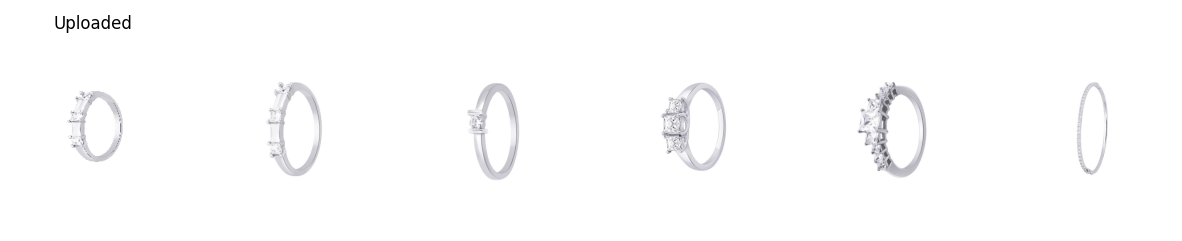

In [31]:
# Pick a random image from the dataset for demo
sample_idx = 123  # you can change this index to try other images
sample_image_path = metadata.iloc[sample_idx]["image_path"]

# Show top 5 recommended similar images
print("Recommended images:")
recommend_similar_images(sample_image_path, n_recommendations=5)


In [32]:
!pip install ftfy regex tqdm transformers

import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# Load CLIP model and processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model.to(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [ ]:
import torch
from tqdm import tqdm
import numpy as np
from PIL import Image

def extract_clip_features(df, batch_size=64):
    clip_model.eval()
    all_features = []

    for i in tqdm(range(0, len(df), batch_size)):
        batch_paths = df["image_path"].iloc[i:i+batch_size]
        images = []

        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                images.append(img)
            except:
                # Use blank image if error
                images.append(Image.new("RGB", (224, 224), (0, 0, 0)))

        # Process batch
        inputs = clip_processor(images=images, return_tensors="pt", padding=True)
        inputs = {k:v.to(device) for k,v in inputs.items()}

        with torch.no_grad():
            features = clip_model.get_image_features(**inputs)
            features = features / features.norm(p=2, dim=-1, keepdim=True)  # normalize
            all_features.append(features.cpu().numpy())

    return np.vstack(all_features)

clip_features = extract_clip_features(filtered_df, batch_size=64)
print("CLIP feature extraction done. Shape:", clip_features.shape)

 76%|███████▌  | 527/695 [36:09<10:51,  3.88s/it]

In [ ]:
np.save("clip_image_features.npy", clip_features)

In [ ]:
# Paths
clip_features_path = "/kaggle/working/clip_image_features.npy"
metadata_path = "/kaggle/working/fashion_metadata.csv"

# Load CLIP features
clip_features = np.load(clip_features_path)
print("CLIP features shape:", clip_features.shape)

# Load metadata
metadata = pd.read_csv(metadata_path)
print("Metadata shape:", metadata.shape)
print(metadata.head())

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityakammati/fashion-recomendation-dataset")

print("Path to dataset files:", path)

In [ ]:
import os

dataset_path = path

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

In [ ]:
import numpy as np
import pandas as pd

# Dynamically get file paths
features_path = os.path.join(dataset_path, "fashion_features.npy")
clip_features_path = os.path.join(dataset_path, "clip_image_features.npy")
metadata_path = os.path.join(dataset_path, "fashion_metadata.csv")
image_path = os.path.join(dataset_path, "hoodie.png")

print("Image path:", image_path)

# Load features
features = np.load(features_path)
print("VGG16 features shape:", features.shape)

# Load CLIP features
clip_features = np.load(clip_features_path)
print("CLIP features shape:", clip_features.shape)

# Load metadata
metadata = pd.read_csv(metadata_path)
print("Metadata shape:", metadata.shape)
print(metadata.head())

In [ ]:
import tensorflow as tf

# Download latest version of the model
model_path = kagglehub.model_download("adityakammati/vgg16-fashion-recommendation/keras/default")
print("Path to model files:", model_path)

# Find the .keras or .h5 file dynamically
model_file = None
for f in os.listdir(model_path):
    if f.endswith(".keras") or f.endswith(".h5"):
        model_file = os.path.join(model_path, f)
        break

if model_file is None:
    raise FileNotFoundError("No .keras or .h5 model file found in the downloaded folder.")

# Load the model
vgg_model = tf.keras.models.load_model(model_file)
print("Model loaded successfully!")

# Optional: print summary
vgg_model.summary()

In [ ]:
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from PIL import Image
import matplotlib.pyplot as plt

# Build KNN model
knn = NearestNeighbors(n_neighbors=5, metric='cosine')
knn.fit(features)

def recommend_similar_images(img_path, n_recommendations=5):
    # Load and preprocess uploaded image
    uploaded_img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(uploaded_img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Extract feature vector using VGG16
    feature_vector = vgg_model.predict(img_array, verbose=0)

    # Find nearest neighbors
    distances, indices = knn.kneighbors(feature_vector, n_neighbors=n_recommendations)

    # Display uploaded + recommended images
    plt.figure(figsize=(15,5))

    # Show uploaded image first
    plt.subplot(1, n_recommendations + 1, 1)
    plt.imshow(uploaded_img)
    plt.title("Uploaded")
    plt.axis("off")

    print(sub_path)

    # Show recommended images
    for i, idx in enumerate(indices[0]):
        rec_img_path = metadata.iloc[idx]["image_path"]
        rec_img_path = rec_img_path.replace("/kaggle/input/fashion-product-images-dataset/fashion-dataset", sub_path)
        # print(rec_img_path)
        rec_img = Image.open(rec_img_path)
        plt.subplot(1, n_recommendations + 1, i + 2)
        plt.imshow(rec_img)
        plt.axis("off")

    plt.show()

# Example usage: replace with your uploaded image
recommend_similar_images(image_path, n_recommendations=5)

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from transformers import CLIPProcessor, CLIPModel
import torch

# Build KNN model on CLIP features
knn_clip = NearestNeighbors(n_neighbors=5, metric='cosine')
knn_clip.fit(clip_features)

# Load CLIP model and processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_clip_feature_from_image(img_path_or_pil):
    """Extract CLIP feature vector from uploaded image"""
    if isinstance(img_path_or_pil, str):
        img = Image.open(img_path_or_pil).convert("RGB")
    else:
        img = img_path_or_pil.convert("RGB")

    inputs = clip_processor(images=img, return_tensors="pt")
    with torch.no_grad():
        features = clip_model.get_image_features(**inputs)
    features = features.cpu().numpy().reshape(-1)
    return features

def recommend_similar_clip_images(img_path, n_recommendations=5):
    """Display similar images using CLIP features"""
    # Extract feature vector
    feature_vector = get_clip_feature_from_image(img_path).reshape(1, -1)

    # Find nearest neighbors
    distances, indices = knn_clip.kneighbors(feature_vector, n_neighbors=n_recommendations)

    # Display recommended images
    plt.figure(figsize=(15,5))

    # Show uploaded image first
    uploaded_img = Image.open(img_path)
    plt.subplot(1, n_recommendations+1, 1)
    plt.imshow(uploaded_img)
    plt.title("Uploaded")
    plt.axis("off")

    for i, idx in enumerate(indices[0]):
        img_path_rec = metadata.iloc[idx]["image_path"]
        img_path_rec = img_path_rec.replace("/kaggle/input/fashion-product-images-dataset/fashion-dataset", sub_path)
        rec_img = Image.open(img_path_rec)
        plt.subplot(1, n_recommendations+1, i+2)
        plt.imshow(rec_img)
        plt.axis("off")

    plt.show()

# Example usage: replace with user-uploaded image path
recommend_similar_clip_images(image_path, n_recommendations=5)

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from transformers import CLIPProcessor, CLIPModel
import torch

# Build KNN model on CLIP features
knn_clip = NearestNeighbors(n_neighbors=5, metric='cosine')
knn_clip.fit(clip_features)

# Load CLIP model and processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def recommend_images_from_text(query, n_recommendations=5):
    """Recommend images based on user text input"""
    # Convert text to CLIP feature vector
    inputs = clip_processor(text=[query], return_tensors="pt", padding=True)
    with torch.no_grad():
        text_features = clip_model.get_text_features(**inputs)
    text_features = text_features.cpu().numpy().reshape(1, -1)

    # Find nearest neighbors
    distances, indices = knn_clip.kneighbors(text_features, n_neighbors=n_recommendations)

    # Display recommended images
    plt.figure(figsize=(15,5))
    plt.suptitle(f"Recommendations for: '{query}'", fontsize=16)

    for i, idx in enumerate(indices[0]):
        img_path_rec = metadata.iloc[idx]["image_path"]
        img_path_rec = img_path_rec.replace("/kaggle/input/fashion-product-images-dataset/fashion-dataset", sub_path)
        rec_img = Image.open(img_path_rec)
        plt.subplot(1, n_recommendations, i+1)
        plt.imshow(rec_img)
        plt.axis("off")

    plt.show()

# Example usage: take input from user
user_query = input("Enter a text description to search images: ")
recommend_images_from_text(user_query, n_recommendations=5)